In [8]:
# ==================== INSTALL & IMPORT ====================
%pip install tslearn --quiet

import numpy as np
from tslearn.metrics import dtw
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize 
from sklearn.utils import resample
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [9]:
# ==================== PREPARE DATA ====================
%run CleanData.ipynb



# Combine X and y for easy sampling
X_combined = np.concatenate([X_train_dtw, X_test_dtw])
y_combined = np.concatenate([y_train_dtw, y_test_dtw])

# Sample 1000 instances for feasibility
X_sample, y_sample = resample(X_combined, y_combined, n_samples=1000, stratify=y_combined, random_state=42)

# Split the sampled data
from sklearn.model_selection import train_test_split
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)




In [10]:
# ==================== TRAIN DTW-KNN ====================
# Retrain model
knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="dtw")
knn_dtw.fit(X_train_small, y_train_small)

c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


KNeighborsTimeSeriesClassifier(n_neighbors=3)

In [11]:
# ==================== EVALUATE MODEL ====================
y_pred_dtw = knn_dtw.predict(X_test_dtw)

# Classification report
print("Classification Report:\n", classification_report(y_test_dtw, y_pred_dtw))

c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92     18952
           1       0.66      0.26      0.37       556
           2       0.74      0.57      0.65      1448
           3       0.48      0.25      0.33       162
           4       0.95      0.87      0.91      1608
           5       0.66      0.20      0.31      2077

    accuracy                           0.86     24803
   macro avg       0.73      0.52      0.58     24803
weighted avg       0.84      0.86      0.83     24803



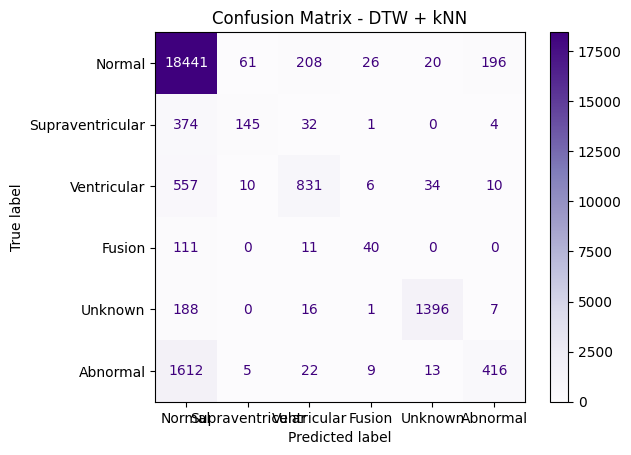

In [12]:
# ==================== CONFUSION MATRIX ====================
label_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown', 'Abnormal']
cm = confusion_matrix(y_test_dtw, y_pred_dtw, labels=np.arange(len(label_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - DTW + kNN")
plt.show()

c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\plui0\AppData\Local\Temp\ipykernel_33592\560051649.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


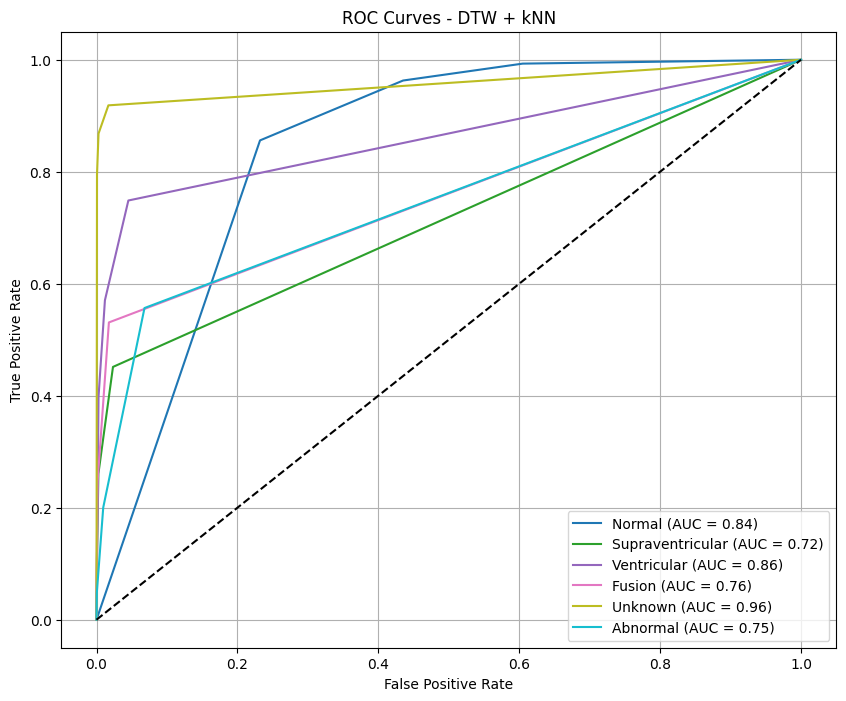

In [13]:
# ==================== ROC & AUC ====================
# Ensure classes are in correct order
classes = np.unique(y_train_dtw)
num_classes = len(classes)
label_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown', 'Abnormal']

# Check if classifier supports predict_proba
if hasattr(knn_dtw, "predict_proba"):
    y_score = knn_dtw.predict_proba(X_test_dtw)
else:
    # Create hard label predictions and one-hot encode
    y_pred_dtw = knn_dtw.predict(X_test_dtw)
    y_score = label_binarize(y_pred_dtw, classes=np.arange(num_classes))

# One-hot encode true labels
y_test_bin = label_binarize(y_test_dtw, classes=np.arange(num_classes))

# Compute ROC curve and AUC
fpr = {}
tpr = {}
roc_auc = {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', num_classes)
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{label_names[i]} (AUC = {roc_auc[i]:.2f})", color=colors(i))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - DTW + kNN")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
